# Compare $\alpha_{base}$ vs $\alpha_{cat1}$

Loads `combined_alpha_sep.csv` (output of `combine_alpha_sep.py`), applies quality cuts, and makes a scatter plot of the baseband spectral index vs the CHIME/CAT1 spectral index with error bars.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Settings

Edit these as needed -- input path and selection criteria.

In [31]:
COMBINED_CSV = "/home/thsu/FRB_population/CHIME_spectra/combined_alpha_sep.csv"

# ---- selection criteria ----
DM_MAX = 300                 # keep rows with dm < DM_MAX
MIN_BANDWIDTH_BASE_MHZ = 300 # keep rows with (freq_top_base - freq_low_base) > this, in MHz

# set to True to also require finite/non-null alpha + error values on both sides
REQUIRE_FINITE_ALPHA = True

## Load data

In [32]:
df = pd.read_csv(COMBINED_CSV)
print(f"loaded {len(df)} rows")
df.head()

loaded 130 rows


,frb_name,dm,freq_top_base,freq_low_base,alpha_base,alpha_err_base,peak_freq_gauss_base,peak_freq_gauss_err_base,freq_top_cat1,freq_low_cat1,alpha_cat1,alpha_err_cat1,peak_freq_cat1,peak_freq_gauss_cat1,peak_freq_gauss_err_cat1,sep_deg
0,FRB20181213A,678.707360,799.609375,400.78125,0.387140,0.031078,665.819690,2.059373,800.195312,400.219727,-0.953620,0.164049,434.58252,434.582520,NaN,0.071167
1,FRB20181214C,632.914866,799.609375,400.78125,-0.024834,0.009567,547.747483,22.726605,800.195312,400.219727,-0.443038,0.120292,459.58252,527.342250,27.930276,0.042285
2,FRB20181215B,494.063603,799.609375,400.78125,0.957896,0.018435,773.207567,12.221166,800.195312,400.219727,0.587028,0.127708,640.83252,578.964691,2.506492,0.144120
3,FRB20181219C,647.919133,799.609375,400.78125,-0.142930,0.013492,526.187481,9.495395,800.195312,400.219727,-1.730437,0.184809,472.08252,472.082520,NaN,0.154080
4,FRB20181221A,316.587191,799.609375,400.78125,-0.351022,0.009943,512.888573,0.515609,800.195312,400.219727,-1.605011,0.203978,515.83252,516.342256,1.190501,0.151535


## Apply criteria

Note: `freq_top_base`/`freq_low_base` are assumed to be in MHz already. If your columns are in GHz, either convert here or change `MIN_BANDWIDTH_BASE_MHZ` to match your units.

In [33]:
mask = pd.Series(True, index=df.index)

mask &= df["dm"] < DM_MAX
mask &= (df["freq_top_base"] - df["freq_low_base"]) > MIN_BANDWIDTH_BASE_MHZ

if REQUIRE_FINITE_ALPHA:
    for col in ["alpha_base", "alpha_err_base", "alpha_cat1", "alpha_err_cat1"]:
        mask &= df[col].notna()

sel = df[mask].copy()
print(f"{len(sel)} / {len(df)} rows pass the criteria")
print(f"  DM < {DM_MAX}")
print(f"  (freq_top_base - freq_low_base) > {MIN_BANDWIDTH_BASE_MHZ} MHz")
sel.head()

29 / 130 rows pass the criteria
  DM < 300
  (freq_top_base - freq_low_base) > 300 MHz


,frb_name,dm,freq_top_base,freq_low_base,alpha_base,alpha_err_base,peak_freq_gauss_base,peak_freq_gauss_err_base,freq_top_cat1,freq_low_cat1,alpha_cat1,alpha_err_cat1,peak_freq_cat1,peak_freq_gauss_cat1,peak_freq_gauss_err_cat1,sep_deg
7,FRB20181223C,112.545432,799.609375,400.78125,-0.107255,0.018710,545.587966,8.904655,800.195312,400.219727,-0.781049,0.169911,509.58252,518.632499,10.844306,0.158703
15,FRB20181231B,197.487908,799.609375,400.78125,-0.151459,0.011665,558.787362,2.350413,800.195312,400.219727,2.340912,0.244204,697.08252,676.960901,3.524658,3.010331
22,FRB20190110C,222.111225,799.609375,400.78125,-0.594634,0.018416,424.968535,1.950619,800.195312,400.219727,-3.667328,0.259313,422.08252,429.836847,1.820387,1.739875
27,FRB20190118A,225.142286,799.609375,400.78125,-2.046801,0.011314,457.409080,0.662301,800.195312,400.219727,-0.493513,0.092598,478.33252,482.389542,1.342222,1.670938
31,FRB20190124F,254.786759,799.609375,400.78125,-0.790702,0.011245,464.083222,2.046837,800.195312,400.219727,-3.294308,0.164711,428.33252,445.438794,9.586355,0.029809


## Scatter plot with error bars (filtered by selection criteria)

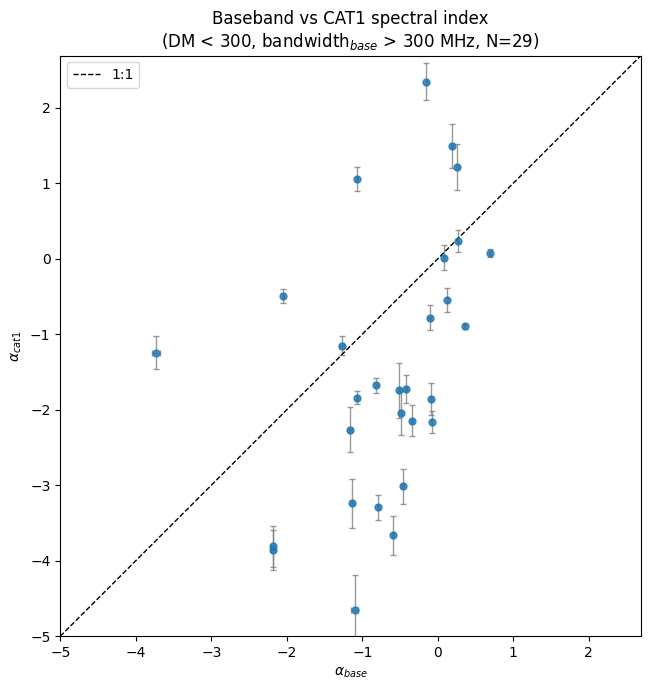

In [34]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.errorbar(
    sel["alpha_base"],
    sel["alpha_cat1"],
    xerr=sel["alpha_err_base"],
    yerr=sel["alpha_err_cat1"],
    fmt="o",
    markersize=5,
    ecolor="gray",
    elinewidth=1,
    capsize=2,
    alpha=0.8,
)

# 1:1 reference line
lo = min(sel["alpha_base"].min(), sel["alpha_cat1"].min())
hi = max(sel["alpha_base"].max(), sel["alpha_cat1"].max())
pad = 0.05 * (hi - lo)
# [x1,x2], [y1,y2] = [lo - pad, hi + pad], [lo - pad, hi + pad]    
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", linewidth=1, label="1:1")
# ax.plot([lo - pad, hi + pad], [hi + pad, lo - pad], "k--", linewidth=1, label="1:1")
ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(lo - pad, hi + pad)
ax.set_xlabel(r"$\alpha_{base}$")
ax.set_ylabel(r"$\alpha_{cat1}$")
ax.set_title(
    f"Baseband vs CAT1 spectral index\n"
    f"(DM < {DM_MAX}, bandwidth$_{{base}}$ > {MIN_BANDWIDTH_BASE_MHZ} MHz, N={len(sel)})"
)
ax.legend()
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()

fig.savefig("alpha_base_vs_cat1.png", dpi=200)
plt.show()

## Peak frequency histograms

Histograms of `peak_freq_cat1` and `peak_freq_gauss_base` using **all data** (not the DM/bandwidth-filtered `sel`), plus the ratio of counts in the 700-800 MHz band to the 400-500 MHz band for each.

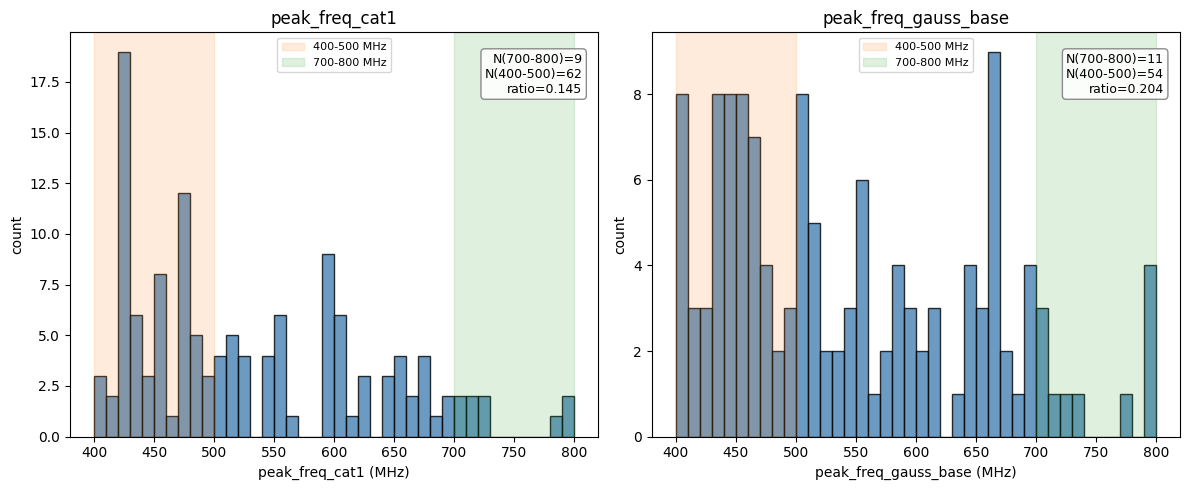

peak_freq_cat1: N(700-800 MHz)=9, N(400-500 MHz)=62, ratio(700-800 / 400-500)=0.145
peak_freq_gauss_base: N(700-800 MHz)=11, N(400-500 MHz)=54, ratio(700-800 / 400-500)=0.204


In [35]:
PEAK_FREQ_COLS = ["peak_freq_cat1", "peak_freq_gauss_base"]
BAND_HIGH = (700, 800)  # MHz
BAND_LOW = (400, 500)   # MHz
BINS = np.arange(400, 810, 10)  # 10 MHz bins spanning both bands; widen/narrow as needed

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

band_counts = {}
for ax, col in zip(axes, PEAK_FREQ_COLS):
    vals = df[col].dropna()
    ax.hist(vals, bins=BINS, color="steelblue", edgecolor="black", alpha=0.8)
    ax.axvspan(*BAND_LOW, color="tab:orange", alpha=0.15, label=f"{BAND_LOW[0]}-{BAND_LOW[1]} MHz")
    ax.axvspan(*BAND_HIGH, color="tab:green", alpha=0.15, label=f"{BAND_HIGH[0]}-{BAND_HIGH[1]} MHz")
    ax.set_xlabel(f"{col} (MHz)")
    ax.set_ylabel("count")
    ax.set_title(col)
    ax.legend(fontsize=8)

    n_high = vals.between(*BAND_HIGH).sum()
    n_low = vals.between(*BAND_LOW).sum()
    ratio = n_high / n_low if n_low > 0 else np.nan
    band_counts[col] = {"n_700_800": n_high, "n_400_500": n_low, "ratio": ratio}

    ax.text(
        0.97, 0.95,
        f"N(700-800)={n_high}\nN(400-500)={n_low}\nratio={ratio:.3f}",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9),
    )

fig.tight_layout()
# fig.savefig("peak_freq_histograms.png", dpi=200)
plt.show()

for col, d in band_counts.items():
    print(
        f"{col}: N(700-800 MHz)={d['n_700_800']}, N(400-500 MHz)={d['n_400_500']}, "
        f"ratio(700-800 / 400-500)={d['ratio']:.3f}"
    )

## Peak frequency (Gaussian fit): baseband vs CAT1, all FRBs

Scatter plot of `peak_freq_gauss_base` vs `peak_freq_gauss_cat1` with error bars from `peak_freq_gauss_err_base` / `peak_freq_gauss_err_cat1`, using all data (no DM/bandwidth cuts).

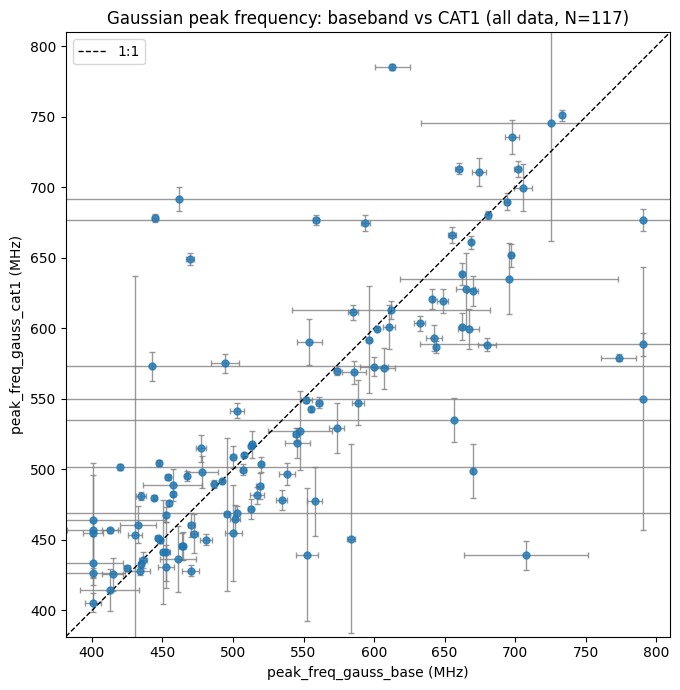

In [36]:
peak_df = df.dropna(
    subset=[
        "peak_freq_gauss_base", "peak_freq_gauss_err_base",
        "peak_freq_gauss_cat1", "peak_freq_gauss_err_cat1",
    ]
)

fig3, ax3 = plt.subplots(figsize=(7, 7))

ax3.errorbar(
    peak_df["peak_freq_gauss_base"],
    peak_df["peak_freq_gauss_cat1"],
    xerr=peak_df["peak_freq_gauss_err_base"],
    yerr=peak_df["peak_freq_gauss_err_cat1"],
    fmt="o",
    markersize=5,
    ecolor="gray",
    elinewidth=1,
    capsize=2,
    alpha=0.8,
)

# 1:1 reference line
lo3 = min(peak_df["peak_freq_gauss_base"].min(), peak_df["peak_freq_gauss_cat1"].min())
hi3 = max(peak_df["peak_freq_gauss_base"].max(), peak_df["peak_freq_gauss_cat1"].max())
pad3 = 0.05 * (hi3 - lo3)
ax3.plot([lo3 - pad3, hi3 + pad3], [lo3 - pad3, hi3 + pad3], "k--", linewidth=1, label="1:1")

ax3.set_xlim(lo3 - pad3, hi3 + pad3)
ax3.set_ylim(lo3 - pad3, hi3 + pad3)
ax3.set_xlabel("peak_freq_gauss_base (MHz)")
ax3.set_ylabel("peak_freq_gauss_cat1 (MHz)")
ax3.set_title(f"Gaussian peak frequency: baseband vs CAT1 (all data, N={len(peak_df)})")
ax3.legend()
ax3.set_aspect("equal", adjustable="box")
fig3.tight_layout()

# fig3.savefig("peak_freq_gauss_base_vs_cat1.png", dpi=200)
plt.show()

## Peak frequency error histograms

Histograms of `peak_freq_gauss_err_base` and `peak_freq_gauss_err_cat1`, using all data.

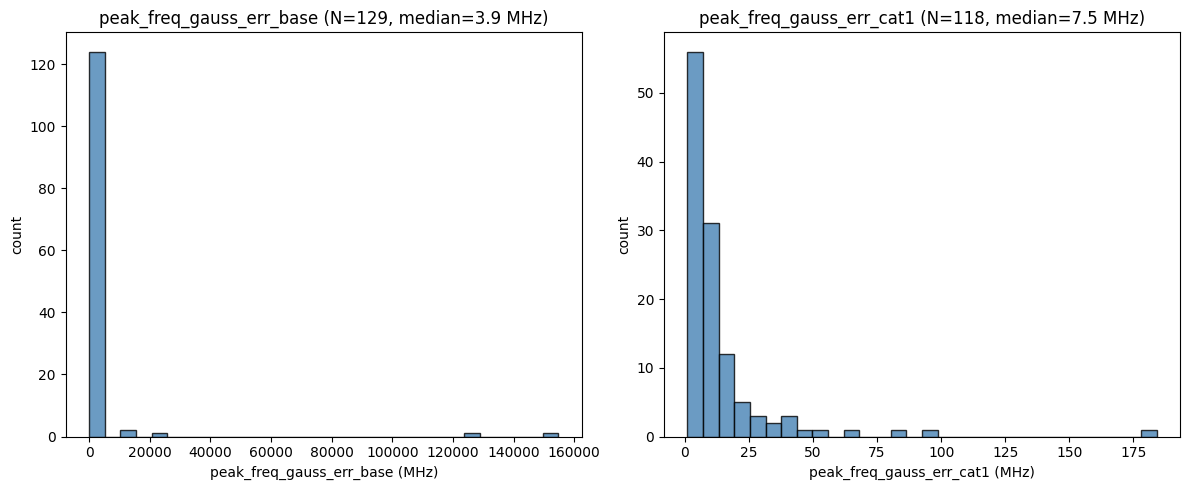

In [37]:
ERR_COLS = ["peak_freq_gauss_err_base", "peak_freq_gauss_err_cat1"]

fig4, axes4 = plt.subplots(1, 2, figsize=(12, 5))


axes4[0].hist(df[ERR_COLS[0]].dropna(), bins=30, color="steelblue", edgecolor="black", alpha=0.8)
axes4[0].set_xlabel(f"{ERR_COLS[0]} (MHz)")
axes4[0].set_ylabel("count")
axes4[0].set_title(f"{ERR_COLS[0]} (N={len(df[ERR_COLS[0]].dropna())}, median={df[ERR_COLS[0]].dropna().median():.1f} MHz)")


axes4[1].hist(df[ERR_COLS[1]].dropna(), bins=30, color="steelblue", edgecolor="black", alpha=0.8)
axes4[1].set_xlabel(f"{ERR_COLS[1]} (MHz)")
axes4[1].set_ylabel("count")
axes4[1].set_title(f"{ERR_COLS[1]} (N={len(df[ERR_COLS[1]].dropna())}, median={df[ERR_COLS[1]].dropna().median():.1f} MHz)")
fig4.tight_layout()
# fig4.savefig("peak_freq_gauss_err_histograms.png", dpi=200)
plt.show()

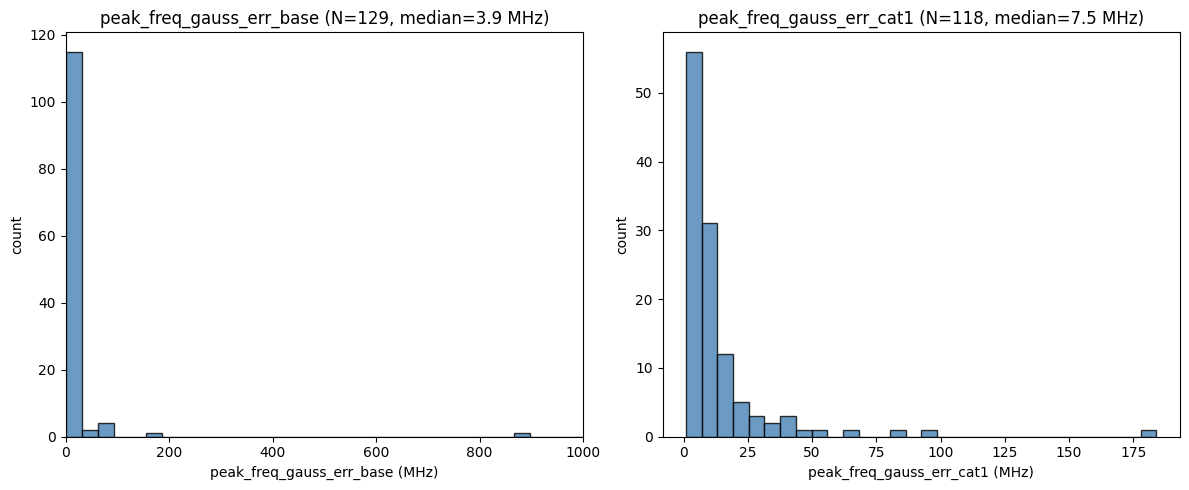

In [38]:
ERR_COLS = ["peak_freq_gauss_err_base", "peak_freq_gauss_err_cat1"]

fig4, axes4 = plt.subplots(1, 2, figsize=(12, 5))


axes4[0].hist(df[ERR_COLS[0]].dropna(), bins=5000, color="steelblue", edgecolor="black", alpha=0.8)
axes4[0].set_xlabel(f"{ERR_COLS[0]} (MHz)")
axes4[0].set_ylabel("count")
axes4[0].set_xlim(0, 1000)
axes4[0].set_title(f"{ERR_COLS[0]} (N={len(df[ERR_COLS[0]].dropna())}, median={df[ERR_COLS[0]].dropna().median():.1f} MHz)")


axes4[1].hist(df[ERR_COLS[1]].dropna(), bins=30, color="steelblue", edgecolor="black", alpha=0.8)
axes4[1].set_xlabel(f"{ERR_COLS[1]} (MHz)")
axes4[1].set_ylabel("count")
axes4[1].set_title(f"{ERR_COLS[1]} (N={len(df[ERR_COLS[1]].dropna())}, median={df[ERR_COLS[1]].dropna().median():.1f} MHz)")
fig4.tight_layout()
# fig4.savefig("peak_freq_gauss_err_histograms.png", dpi=200)
plt.show()